# CLIPS Constructs

Refer details from lecture notes 6.

# Section A: Agenda

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deftemplate person
           (multislot name)
           (multislot children))""")

env.build("""(deffacts some-people
           (person (name John Q. Public)
                   (children Jane Paul Mary))
           (person (name Jack R. Public)
                   (children Risk)))""")

env.build("""(defrule print-children
           (person (name $?name)
                   (children $?children))
        =>(printout t $?name " has children " $?children
                     crlf))""")

env.reset()

# Method 1: Display agenda
# LIFO order for deffacts
# active = env.activations()
# i = 1
# for act in active:
#     print(f"Fire {i} : Rule {act.name}-{act.salience}")
#     i+=1
    
# Method 2: Use the command in CLIPS
env.eval("(agenda)")
env.run()

# After perform run, the agenda will be cleared automatically


# Section B: Pattern Matching

1. **Fire rule unconditionally**

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deffacts startup (animal dog) (animal cat) (animal duck) (animal turtle) 
                  (warm-blooded dog) (warm-blooded cat) (warm-blooded duck) 
                  (lays-eggs duck) (lays-eggs turtle) (child-of dog puppy) 
                  (child-of cat kitten) (child-of turtle hatchling))""")

env.build("""(defrule animal
  =>
  (printout t "animal found" crlf))""")

env.reset()
env.run()

2. **Pattern-matching wildcards**

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deffacts startup (animal dog) (animal cat) (animal duck) (animal turtle) 
                  (warm-blooded dog) (warm-blooded cat) (warm-blooded duck) 
                  (lays-eggs duck) (lays-eggs turtle) (child-of dog puppy) 
                  (child-of cat kitten) (child-of turtle hatchling))""")

# single-field wildcard (?). E.g. (animal cat)
# multifield wildcard ($?). E.g. (animal cat dog)
env.build("""(defrule animal
  (animal ?)
  =>
  (printout t "animal found" crlf))""")

env.reset()
env.run()

3. Display **pattern-matching variable**

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deffacts startup (animal dog) (animal cat) (animal duck) (animal turtle) 
                  (warm-blooded dog) (warm-blooded cat) (warm-blooded duck) 
                  (lays-eggs duck) (lays-eggs turtle) (child-of dog puppy) 
                  (child-of cat kitten) (child-of turtle hatchling))""")

env.build("""(defrule list-animals
(animal ?name)
=>
(printout t ?name " found" crlf))""")

env.reset()
env.run()

4. **Fact assertion** for **pattern-matching variable**

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deffacts startup (animal dog) (animal cat) (animal duck) (animal turtle) 
                  (warm-blooded dog) (warm-blooded cat) (warm-blooded duck) 
                  (lays-eggs duck) (lays-eggs turtle) (child-of dog puppy) 
                  (child-of cat kitten) (child-of turtle hatchling))""")

env.build("""(defrule mammal
  (animal ?name)
  (warm-blooded ?name)
  (not (lays-eggs ?name))
  =>
  (assert (mammal ?name))
  (printout t ?name " is a mammal" crlf))""")

env.reset()
env.run()


5. **Retract fact** in rules

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deffacts startup (animal dog) (animal cat) (animal duck) (animal turtle) 
                  (warm-blooded dog) (warm-blooded cat) (warm-blooded duck) 
                  (lays-eggs duck) (lays-eggs turtle) (child-of dog puppy) 
                  (child-of cat kitten) (child-of turtle hatchling))""")

env.build("""(defrule remove-warm-blooded
  ?fact <- (warm-blooded ?)
  =>
  (printout t "retracting " ?fact crlf)
  (retract ?fact))""")

env.reset()
env.run()

for fact in env.facts():
    print(fact)

6. **retract** the user’s input word and replace it with its normalized form. Advanced method, use NLP.

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deffacts dictionary
   (base-form ran run)
   (base-form running run)
   (base-form run run))""")


env.build("""(defrule normalize
   ?q <- (query ?w)
   (base-form ?w ?base)
   (test (neq ?w ?base))    ;; Only normalize if different
   =>
     (retract ?q)
     (assert (query ?base))
     (printout t "Normalized: " ?w " → " ?base crlf))""")

env.reset()

env.eval("(assert (query ran))")
env.eval("(facts)")

env.run()

# Replacing the facts (query ran) to (query run)
env.eval("(facts)")


# Section C: Field Constraints and Connective Constraints

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deftemplate person
               (slot name)
               (slot eyes)
               (slot hair))""")

#Find a person with blue eyes.
env.build("""(defrule find-blue-eyes
               (person (name ?name)
                       (eyes blue))
             =>(printout t ?name " has blue eyes." crlf))""")

# Find a person without brown hair.
env.build("""(defrule find-without-brown-hair
               (person (name ?name)
                       (hair ~brown))
             =>(printout t ?name " does not have brown hair" crlf))""")

#Find a person with either black or brown hair.
env.build("""(defrule find-black-or-brown-hair
               (person (name ?name)
                       (hair black|brown))
             =>(printout t ?name " has dark hair" crlf))""")

#Find a person with either black or brown hair. Specify the color of the hair.
env.build("""(defrule find-black-or-brown-hair
               (person (name ?name)
                       (hair ?color& black | brown))
             =>(printout t ?name " has " ?color " hair" crlf))""")

#Find a person with neither black nor brown hair. Specify the color of the hair.
env.build("""(defrule find-black-nor-brown-hair
               (person (name ?name)
                       (hair ?color& black & ~brown))
             =>(printout t ?name " has " ?color " hair" crlf))""")

env.reset()

env.assert_string('(person (name Tawfeeq)(eyes blue))')
env.assert_string('(person (name Kaviraj)(hair black))')
env.assert_string('(person (name "Siti Nabila")(hair brown))')
                  
env.run()

# Section D: Predicate Field Constraints

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deftemplate rectangle
               (slot height)
               (slot width))""")

#Predicate Field Constraints, (height ?height&:(< ?height 12))
env.build("""(defrule sum-rectangles
                (rectangle (height ?height&:(> ?height 0)&:(< ?height 12)) (width ?width&:(> ?width 5)))
              =>
             (printout t "Rectangle meets the size criteria" crlf))""")

env.reset()

env.assert_string("(rectangle (height 5) (width 10))")

env.run()

#for fact in env.facts():
#    print(fact)

# Section E: Return Value Constraints

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deftemplate rectangle
               (slot height)
               (slot width))""")

#Return Value Constraints =, ~=
env.build("""(defrule check-size
               (rectangle (height ?height) (width = (* 2 ?height)))
              =>(printout t "Verified width is double of height" crlf))""")

env.reset()

env.assert_string("(rectangle (height 5) (width 10))")

env.run()


# Section F: Test Construct

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

# Define a simple rule
env.build("""
(defrule example
  (test (greater-or-equal 10 5))
  =>
  (printout t "10 is greater than or equal to 5" crlf))
""")

env.reset()

env.run()


# Section G: Modify Fact in Rule ( <- )

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deftemplate rectangle
               (slot height)
               (slot width))""")

env.build("""(defrule sum-rectangles
                 ;; assign the fact value to a variable
                 ?r<-(rectangle (height ?height) (width ?width))
             =>
             ;; modify the fact slot value 
             (modify ?r (width 30)))""")

env.reset()

env.assert_string("(rectangle (height 5) (width 10))")

env.run()

for fact in env.facts():
    print(fact)

# Section H: Return Values from Rule

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deftemplate rectangle
               (slot height)
               (slot width))""")

env.build("""(defrule sum-rectangles
                 (rectangle (height ?height) (width ?width))
              =>
             (assert (area (* ?height ?width))))""")

env.reset()

env.assert_string("(rectangle (height 5) (width 10))")

env.run()

for fact in env.facts():
    if fact.template.name == "area":
        print('Area:' + str(fact[0]))

# Section I: Built-in Functions & Expressions

1. Evaluate mathematic **expression**

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

# In CLIPS (assert (sum (+ 3 5 7)))
env.eval('(+ 3 5 7)')

# Minus
env.eval('(- 5 3)')

# Multiply
env.eval('(* 5 3)')

# Division
env.eval('(/ 5 2)')

# Power of
env.eval('(** 2 5)')

# Sqrt of
env.eval('(sqrt 8)')

# Log base 10
env.eval('(log10 8)')

# Mod
env.eval("(mod 10 7)")

# Floor Division ??????
#env.eval('(// 5 2)')

# Floor Division - Mixture Python with CLIPS
env.eval(f'(* {5 // 2} 1)')



2. Evaluate mathematic **expression** with **fact assertion**

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.reset()

value = env.eval('(+ 3 5 7)')
env.assert_string(f"(sum {value})")

# Mixture of Python and clipspy
#env.assert_string(f"(sum {3 + 5 + 7})")

env.run()

for fact in env.facts():
    print(fact)

3. **Summing values** in rules

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(defrule calculate-sum
                   (sum ?n1 ?n2)
             => (printout t (+ ?n1 ?n2) crlf))""")

env.reset()

env.assert_string('(sum 1 2)')

env.run()

* This will make the infinity loop

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""
(deftemplate rectangle
    (slot height)
    (slot width))
""")

env.build("""(deffacts initial-information
                (rectangle (height 10) (width 6))
                (rectangle (height 7) (width 5))
                (rectangle (height 6) (width 8))
                (rectangle (height 2) (width 5))
                (sum 0))""")

env.build("""(defrule sum-rectangles
                (rectangle (height ?height) (width ?width))
                ?sum <- (sum ?total)
                =>
                (retract ?sum)
                (assert (sum (+ ?total (* ?height ?width)))))
        """)


env.reset()

env.run()

* Fix it!

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""
(deftemplate rectangle
    (slot height)
    (slot width))
""")

env.build("""(deffacts initial-information
                (rectangle (height 10) (width 6))
                (rectangle (height 7) (width 5))
                (rectangle (height 6) (width 8))
                (rectangle (height 2) (width 5))
                (sum 0))""")

env.build("""(defrule sum-rectangles
                (rectangle (height ?height) (width ?width))
              => (assert (add-to-sum (* ?height ?width))))""")

env.build("""(defrule sum-areas
                ?sum<-(sum ?total)
                ?new-area<-(add-to-sum ?area)
              => (retract ?sum ?new-area)
                 (assert (sum (+ ?total ?area))))""")

env.reset()

env.run()

env.eval('(facts)')

# Section J: Create a User-Defined Function

1. Calling a **user-defined function**.

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deffunction calculate-area 
                       (?length ?width) (* ?length ?width))""")

# (assert (area (calculate-area 2 3)))
env.assert_string(f"(area (calculate-area 2 3))")

#area= env.eval(f"(calculate-area 2 3)")
#env.assert_string(f"(area {area})")

env.run()

for fact in env.facts():
    print(fact)

2. **Passing data** in a **user-defined function** with **parameter values** 

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deffunction calculate-area(?x ?y)
                       (return (* ?x ?y)))""")

#(deffunction main()
#        (printout t "Area = " (calculate-area 3 5)))
#(main)"

value=env.eval("(calculate-area 3 5)")
print("Area = ", value)


3. Return **tuple** from **user-defined function**. Return more than one values.

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deffunction coordinate(?x ?y)
                       (return (create$ ?x ?y)))""")

value=env.eval("(coordinate 3 5)")
print("Area = ", value)


# Section K: Global Variables

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(defglobal ?*x* = 10)""")

env.reset()

env.assert_string("""(value (* ?*x* 2))""")

env.run()

for fact in env.facts():
    print(fact)

# Section L: Bind Functions

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(defrule get-name
             =>(printout t "What is your name? " crlf)
               (bind ?response "Tee Xue Ni")
               (printout t "I'm " ?response crlf)
               (bind ?response "Lim Hui Jun")
               (printout t "Sorry, I'm " ?response crlf))""")

env.reset()

env.run()


# Section M: Logical Condition

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.reset()

# (assert (status (if (> 2 1) then "valid" else "invalid"))
value = env.eval('(if (> 2 1) then "valid" else "invalid")')
env.assert_string(f"(status {value}))")

# Mixture of Python and clipspy
#env.assert_string(f"(status {'valid' if 2 > 1 else 'invalid'})")

#py_logical_condition = 'valid' if 2 > 1 else 'invalid'
#env.assert_string(f"(status {py_logical_condition})")

for fact in env.facts():
    print(fact)

# Section N: Exists Condition

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deftemplate emergency (slot type))""")

env.build("""(defrule operator-alert-for-emergency
                (exists (emergency))
                (not (operator-alert))
             =>
                (printout t "Emergency: Operator Alert" crlf)
                (assert (operator-alert)))""")

env.reset()

env.assert_string("(emergency (type 'fire'))")

env.run()


# Section O: Forall

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("""(deftemplate emergency 
               (slot type)
               (slot location))""")

env.build("""(deftemplate fire-squad 
               (slot name)
               (slot location))""")

env.build("""(deftemplate evacuated 
               (slot building))""")

# Define the rule using `forall`
env.build("""
(defrule all-fires-handled
   (forall
      (emergency (type fire) (location ?loc))
      (and
         (fire-squad (location ?loc))
         (evacuated (building ?loc))))
   =>
   (printout t "All fire emergencies are handled: firefighters are present, and buildings are evacuated." crlf))
""")

# Assert facts
env.assert_string("(emergency (type fire) (location building-1))")
env.assert_string("(emergency (type fire) (location building-2))")
env.assert_string("(fire-squad (name squad1) (location building-1))")
env.assert_string("(fire-squad (name squad2) (location building-2))")
env.assert_string("(evacuated (building building-1))")
env.assert_string("(evacuated (building building-2))")

env.run()


# Section P: logical construct for Truth Maintenance System (TMS)

-   Fact consistency in working memory means that logical dependencies are maintained automatically.
    For example, if we define the rule p → q:
    - When p is present in working memory, q is derived.
    - If p is later retracted, the system must also retract q so that the working memory stays consistent.

1. Fact inconsistency in working memory

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("(deftemplate p (slot value))")

env.build("(deftemplate q (slot value))")

env.build("""
(defrule infer-q
   (p (value TRUE))   
   =>
   (assert (q (value TRUE)))   
)""")

env.build("""
(defrule print-q
   (q (value ?v))
   =>
   (printout t "Q is " ?v crlf))""")

env.reset()  

env.eval("(assert (p (value TRUE)))")

env.run()     

env.eval("(facts)")

env.eval("(retract 1)")
env.run() 
env.eval("(facts)")

2. Fact consistency in working memory

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

env.build("(deftemplate p (slot value))")

env.build("(deftemplate q (slot value))")

env.build("""
(defrule infer-q
   (logical (p (value TRUE)))   
   =>
   (assert (q (value TRUE)))   
)""")

env.build("""
(defrule print-q
   (q (value ?v))
   =>
   (printout t "Q is " ?v crlf))""")

env.reset()  

env.eval("(assert (p (value TRUE)))")

env.run()     

env.eval("(facts)")

env.eval("(retract 1)")
env.run() 
env.eval("(facts)")

# Exercises:

1. Differentiate **(name ?response)**, **(bind ?response "abc")**, **(?response<-(animal 'Garfield'))** in **defrule**.

In [ ]:
#Hints:
#1. (name ?response) - 
#2. (bind ?response "abc") - 
#3. (?response<-(animal 'Garfield')) - 

2. Rewrite the expression **10+4*19-35/12** in CLIPS notation and verify that you get the **result 83.0833**.

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

#To Do#


3. Write an expert system that gets user input and **gives advice** on the discount rate given.

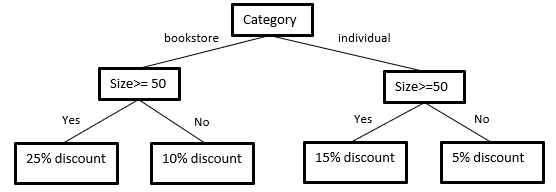

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

#To Do#

4. Write a rule based expert system to determine **even number** when user provide the inputs. (**Hints**: Must use **defrule** without calling **user-defined function**)

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

#To Do#

5. Define two **deftemplate** (**student** and **programme**) and simulate the **left join**, **right join** and **outer join** implementation.

In [ ]:
import clips 
import logging

# Setup working environment
logging.basicConfig(level=logging.INFO,format='%(message)s')
    
env = clips.Environment()
router = clips.LoggingRouter()
env.add_router(router)

#To Do#